# Лабораторная 1. Очистка набора данных

# Подключение модулей

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor


# Загрузка данных (регрессия)

В данной задаче у нас данные по недельным продажам сети Walmart.

In [2]:
df = pd.read_csv('Walmart.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Описательная статистика

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [4]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


Стандартные функции pandas не выводят всю необходимую описательную статистику, поэтому создадим свою таблицу с описательной статистикой. Для удобства закрасим признаки с единичной мощностью и большим количеством пропусков, чтобы потом их было легче удалить.

In [5]:
C = len(df.columns)
L = len(df.index)
CN = df.count()  # количество
NP = ((L - CN) / L) * 100  # процент пропущенных значений
MN = df.min()  # минимум
Q1 = df.quantile(q=0.25)  # первый квартиль
MA = df.mean()  # среднее значение
ME = df.median()  # медиана
Q3 = df.quantile(q=0.75)  # третий квартиль
MX = df.max()  # максимум
ST = df.std()  # стандартное отклонение
P = df.nunique()  # мощность
IQ = Q3 - Q1  # интерквартильный размах

frame = pd.concat([CN, NP, MN, Q1, MA, ME, Q3, MX, ST, P, IQ], axis=1, join="inner")
frame = frame.T
f = pd.DataFrame(frame)
f.index = ['Количество', 'Процент пропусков', 'Минимум', 'Первый квартиль', 'Среднее', 'Медиана', 'Третий квартиль', 'Максимум', 'Стандартное отклонение', 'Мощность', 'Интерквартильный размах']
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
f1 = f.style.apply(lambda x: ["background-color:tomato" if i == 1 else "" for i in x], axis=1, subset=(['Мощность'], slice(None))).apply(lambda x: ["background-color:tomato" if i >= 60 else "" for i in x], axis=1, subset=(['Процент пропусков'], slice(None))).apply(lambda x: ["background-color:steelblue" if (i < 30 and i > 0) else "" for i in x], axis=1, subset=(['Процент пропусков'], slice(None))).apply(lambda x: ["background-color:limegreen" if i == 0 else "" for i in x], axis=1, subset=(['Процент пропусков'], slice(None)))
f1


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Количество,6435,6435,6435,6435,6435,6435,6435,6435
Процент пропусков,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Минимум,1,2010-02-05 00:00:00,209986.250000,0,-2.060000,2.472000,126.064000,3.879000
Первый квартиль,12.000000,2010-10-08 00:00:00,553350.105000,0.000000,47.460000,2.933000,131.735000,6.891000
Среднее,23.000000,2011-06-17 00:00:00,1046964.877562,0.069930,60.663782,3.358607,171.578394,7.999151
Медиана,23.000000,2011-06-17 00:00:00,960746.040000,0.000000,62.670000,3.445000,182.616521,7.874000
Третий квартиль,34.000000,2012-02-24 00:00:00,1420158.660000,0.000000,74.940000,3.735000,212.743293,8.622000
Максимум,45,2012-10-26 00:00:00,3818686.450000,1,100.140000,4.468000,227.232807,14.313000
Стандартное отклонение,12.988182,288 days 23:30:02.771679932,564366.622054,0.255049,18.444933,0.459020,39.356712,1.875885
Мощность,45,143,6435,2,3528,892,2145,349


Удалим признаки, у которых мощность равна 1 и пропусков слишком много

In [6]:
df = df.drop(['Date', 'Holiday_Flag'], axis=1)

# Тепловая карта

<Axes: >

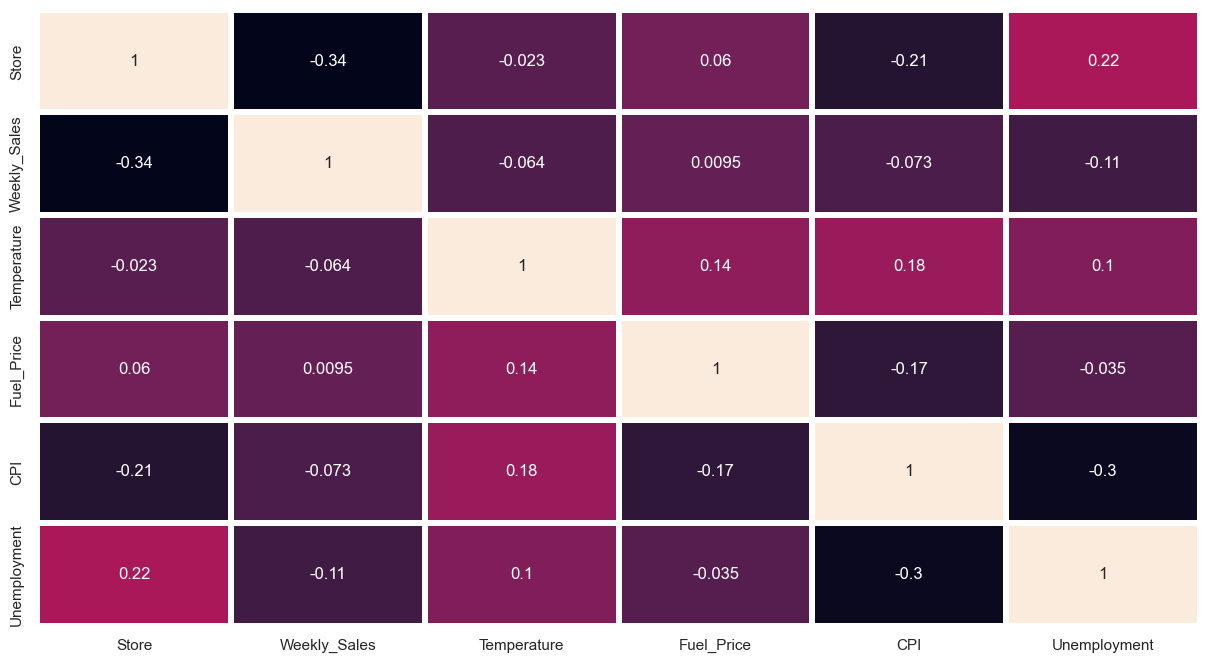

In [7]:

sns.set(rc={'figure.figsize': (15, 8)})
sns.heatmap(df.corr(), annot=True, linewidths=3, cbar=False)


# Распределения

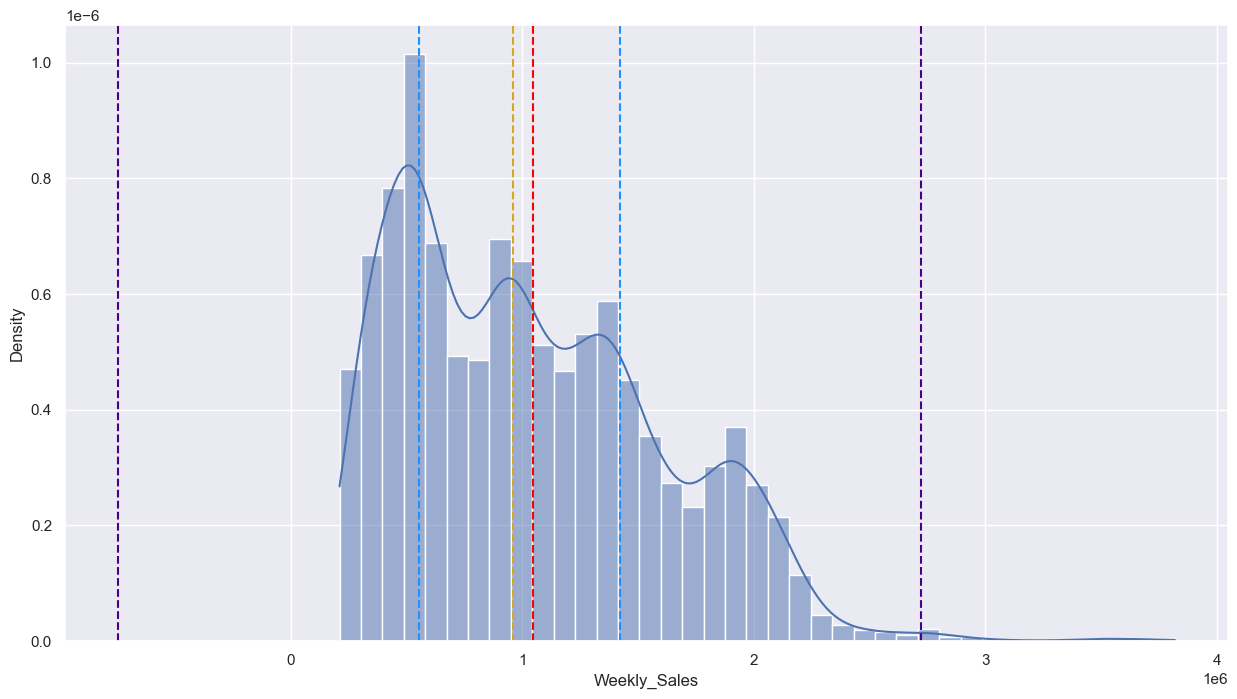

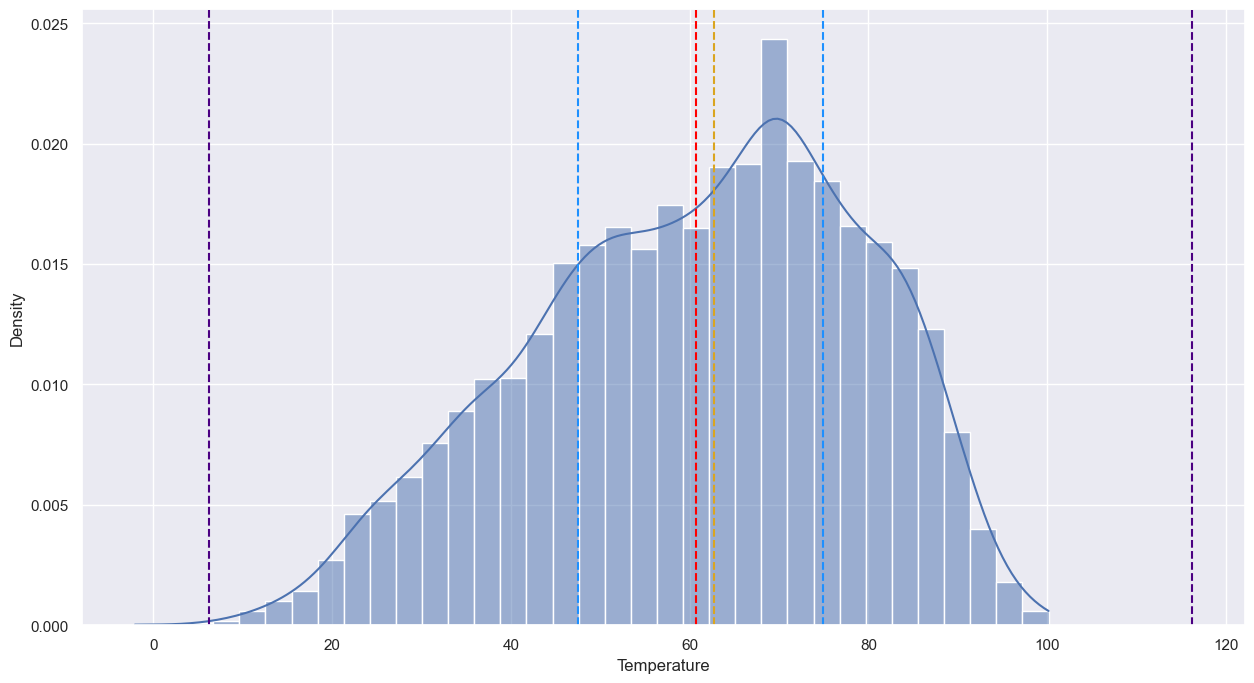

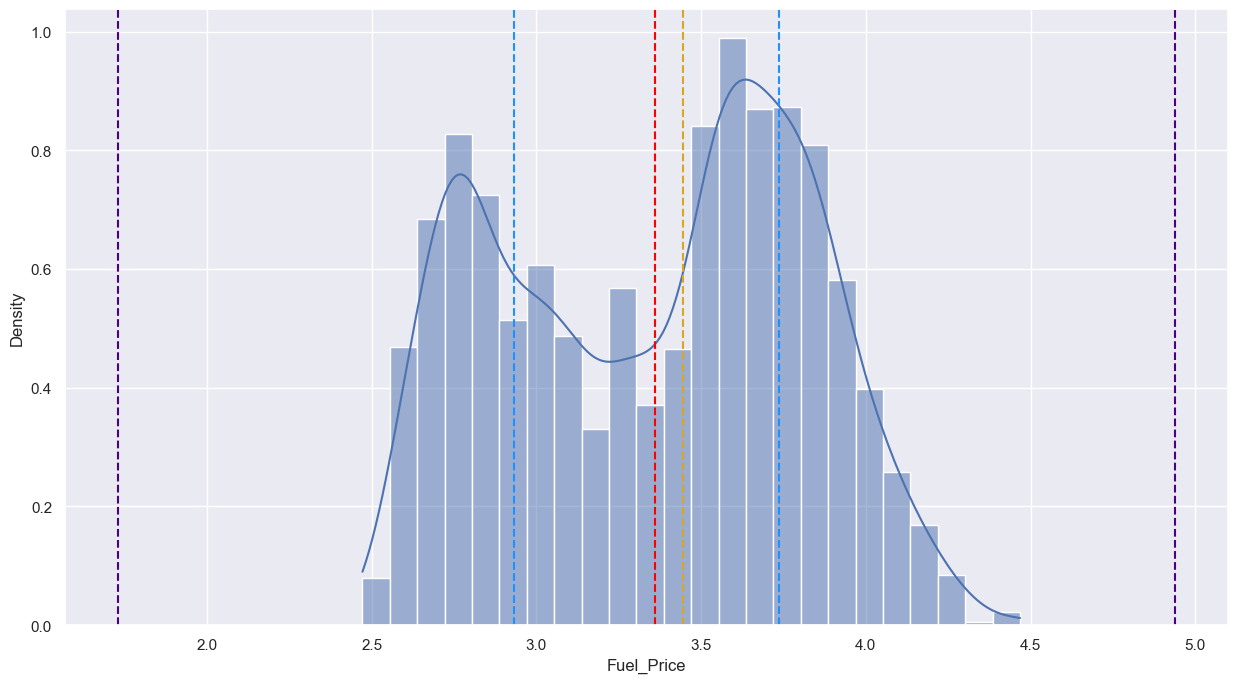

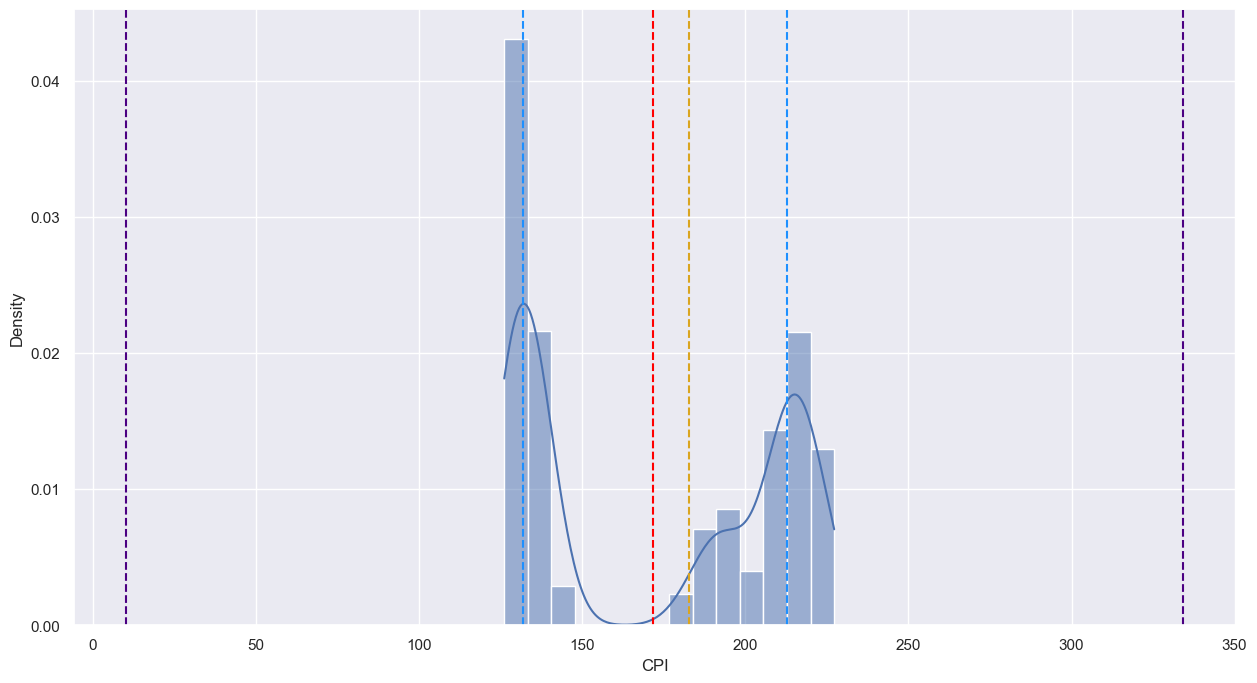

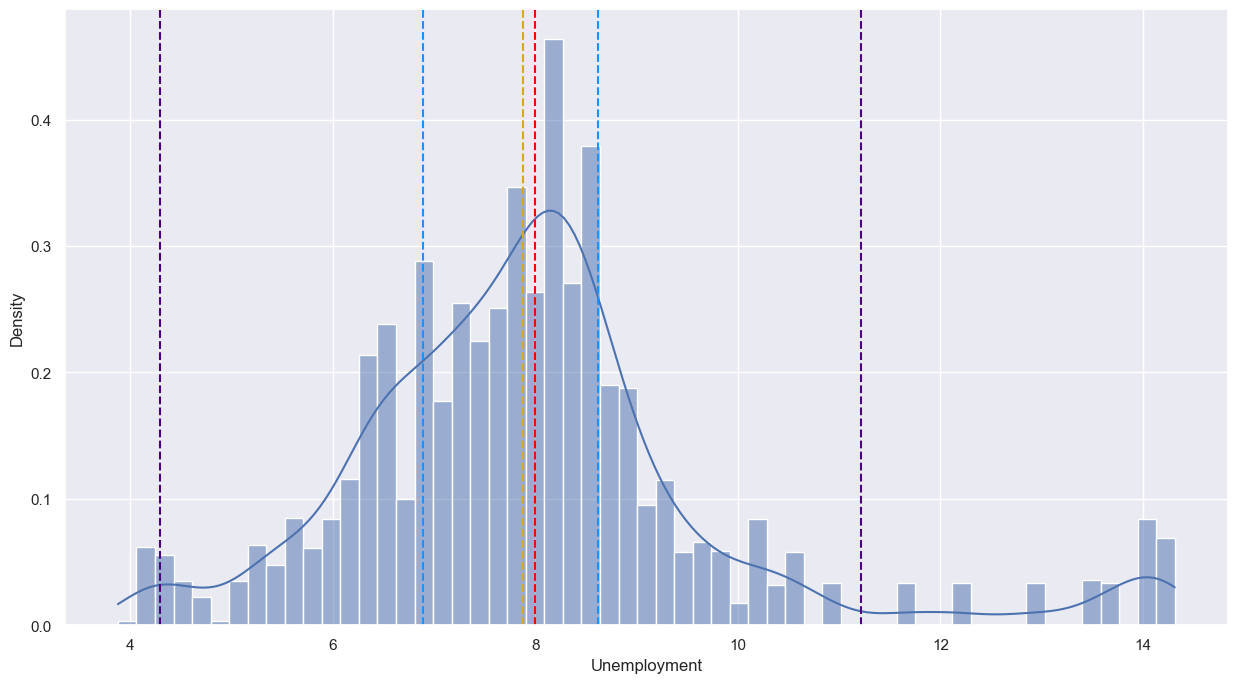

In [8]:

for i in df.columns[1:]:
    plt.figure(i)
    sns.histplot(df[i], kde=True, stat="density")
    plt.axvline(f.iloc[3][i] - 1.5 * f.iloc[10][i], color="indigo", ls='--')  # q1-1.5*iqr
    plt.axvline(f.iloc[3][i], color="dodgerblue", ls='--')  # первый квартиль
    plt.axvline(f.iloc[4][i], color="red", ls='--')  # среднее
    plt.axvline(f.iloc[5][i], color="goldenrod", ls='--')  # медиана
    plt.axvline(f.iloc[6][i], color="dodgerblue", ls='--')  # третий квартиль
    plt.axvline(f.iloc[6][i] + 1.5 * f.iloc[10][i], color="indigo", ls='--')  # q3+1.5*iqr
    plt.show()


Также полезно посмотреть на диаграммы рассеяния, показывающие возможную зависимость между признаками. В нашем случае, посмотрим на связь между признаками и целевой переменной.

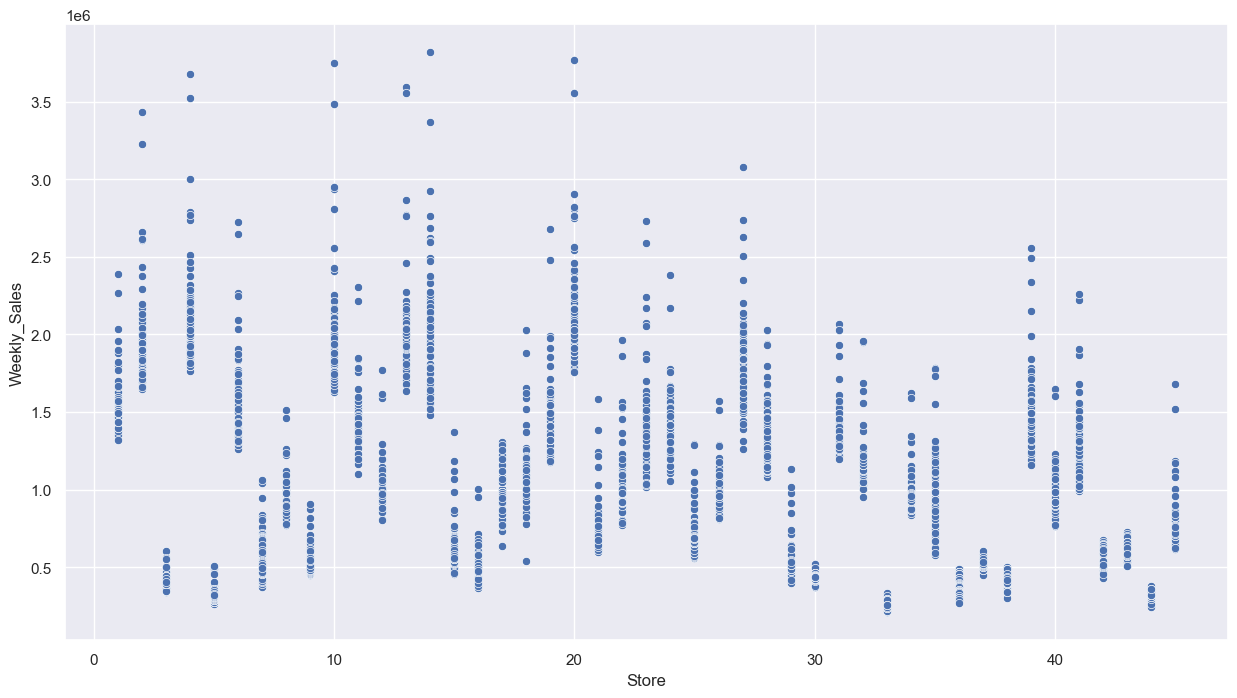

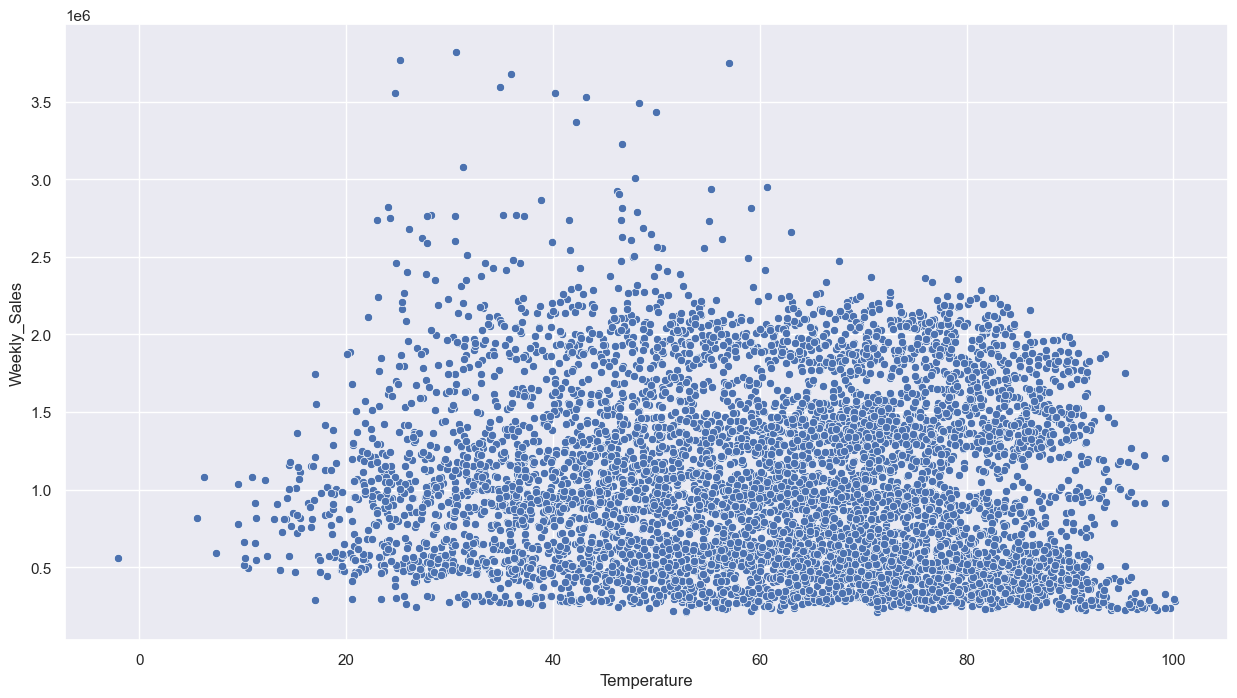

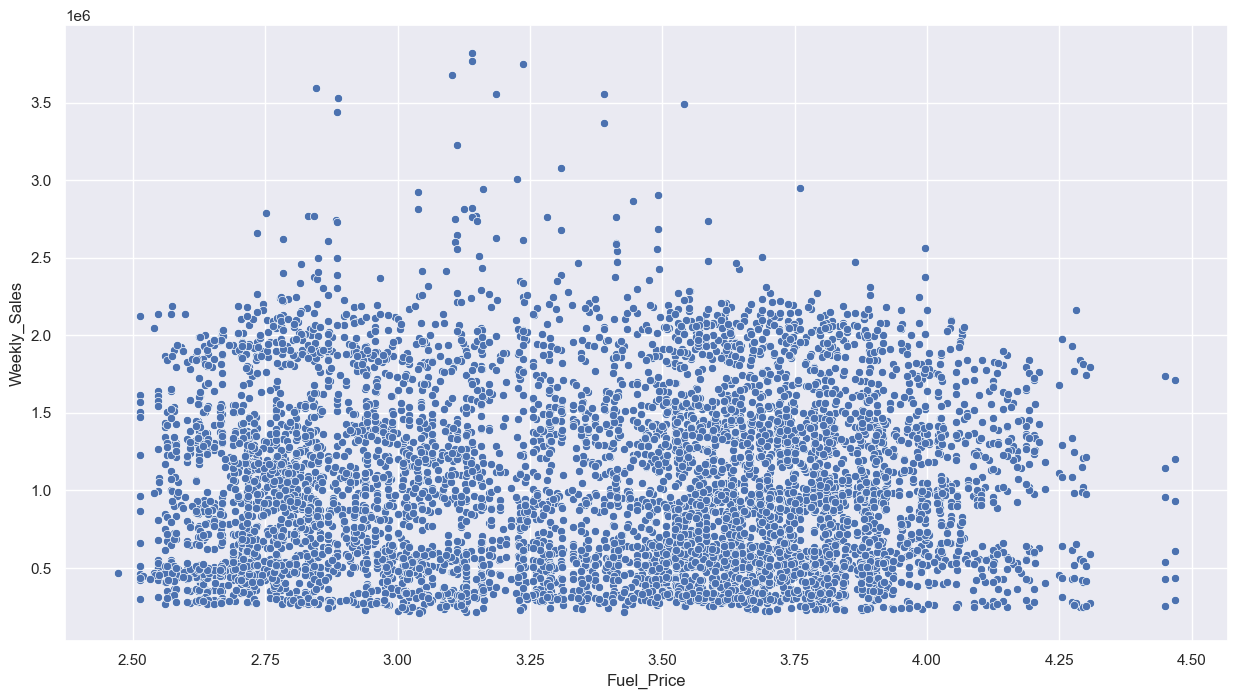

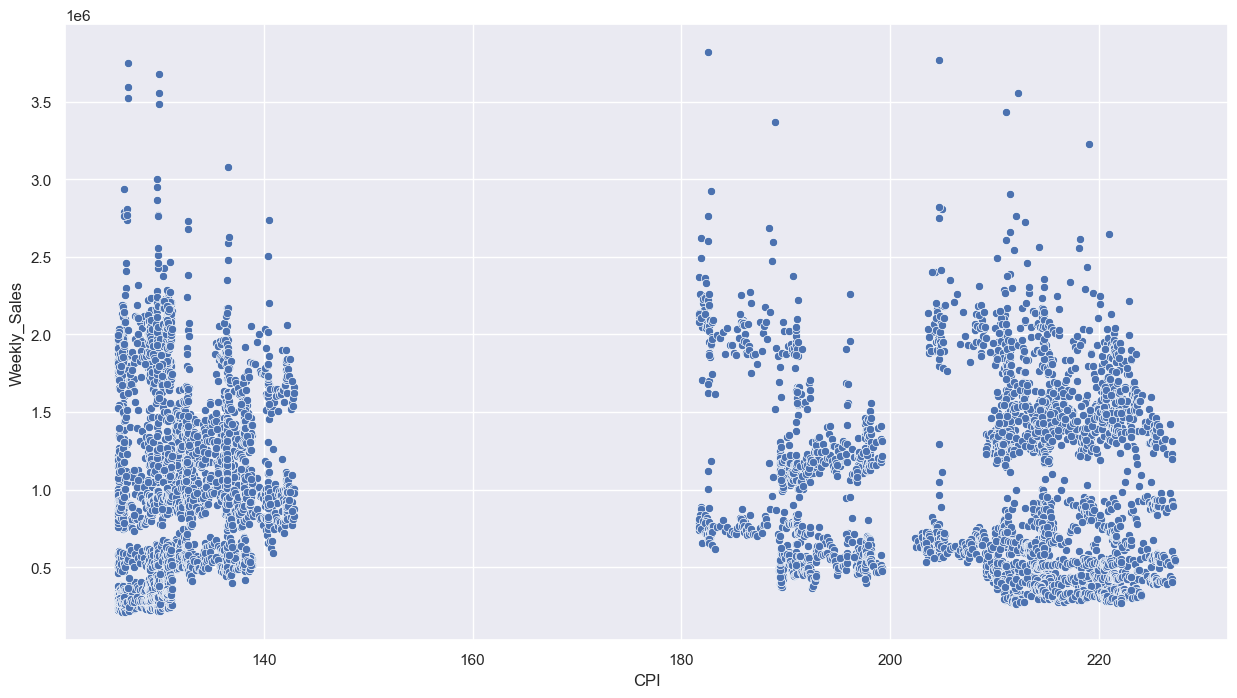

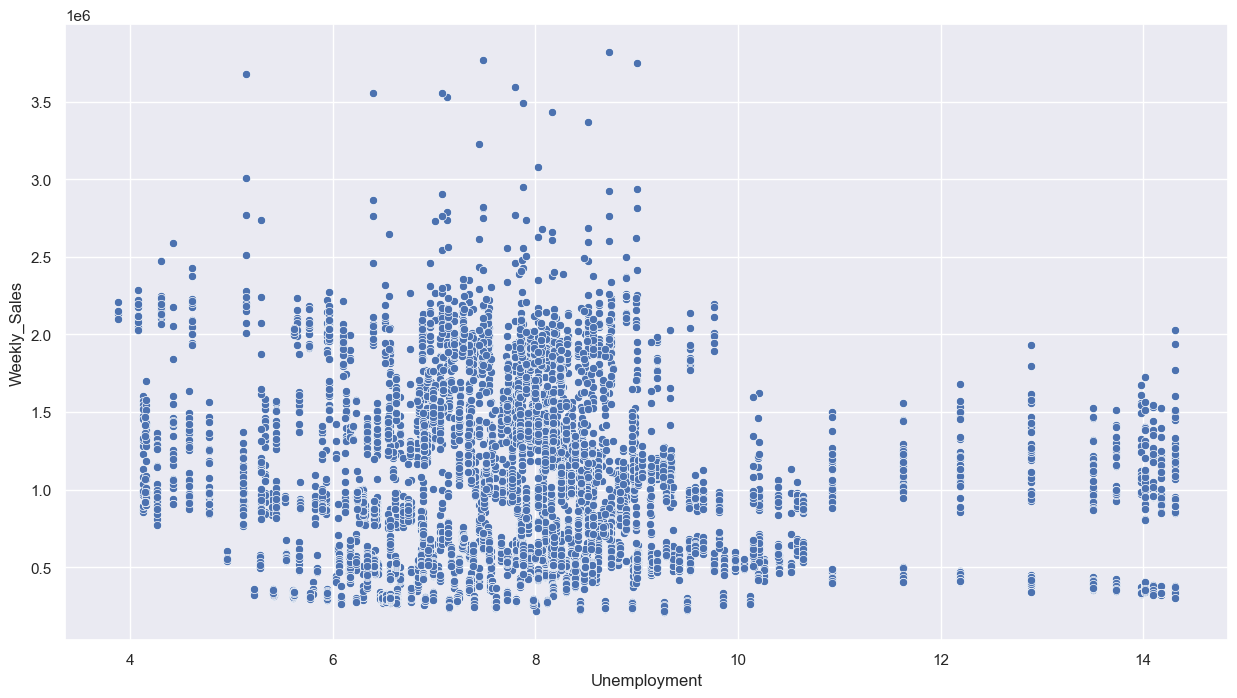

In [9]:

X1 = df.drop(columns=['Weekly_Sales'])

for i in X1.columns:
    plt.figure(i)
    sns.scatterplot(data=df, y='Weekly_Sales', x=i)
    plt.show()


# Важность признаков

In [10]:

df1 = df.fillna(-100)
X = df1.drop(columns=['Weekly_Sales'])
Y = df1['Weekly_Sales']

regr = RandomForestRegressor(max_depth=20, random_state=0)
regr.fit(X, Y)


RandomForestRegressor(max_depth=20, random_state=0)

<Axes: >

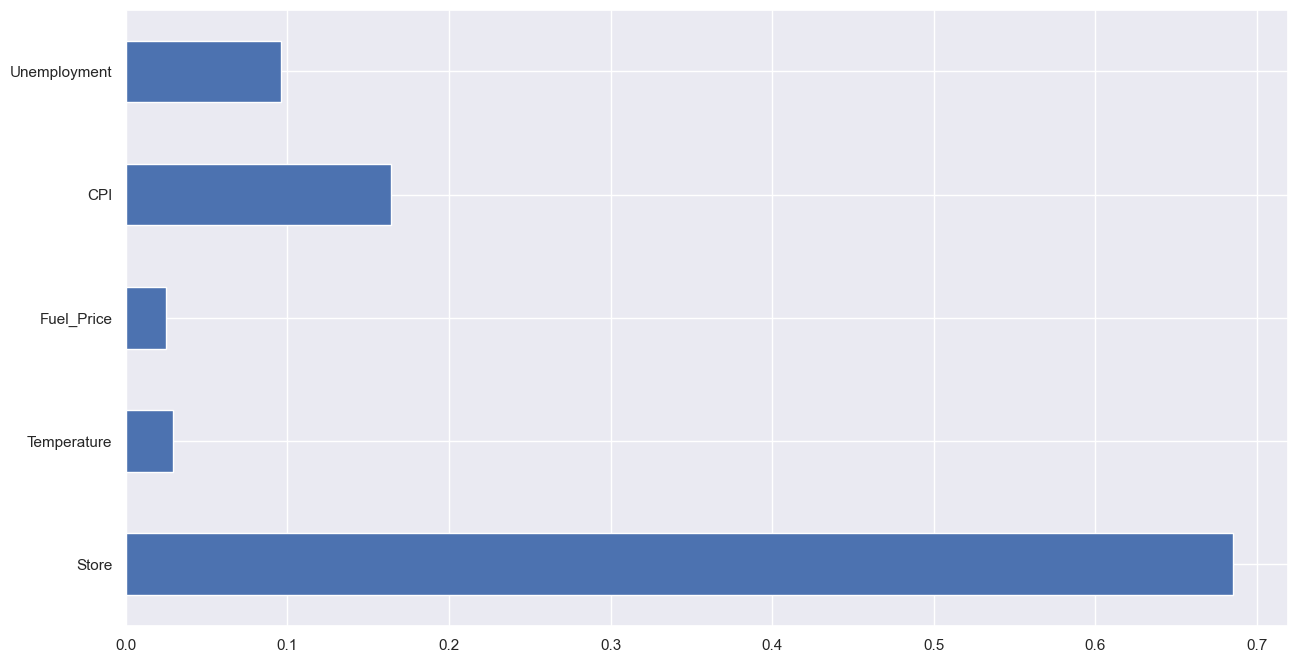

In [11]:

feat_importances = pd.Series(regr.feature_importances_, index=X.columns)
feat_importances.plot(kind='barh')


# Выводы

На основе проведенного анализа можно сформировать первичное представление о значимости признаков и распределениях целевой переменной.

# Дополнительная подготовка данных Walmart

Далее воспроизводим полный цикл подготовки данных: согласование типов, заполнение пропусков, удаление выбросов, генерация признаков, масштабирование и кодирование категорий.

In [12]:
import numpy as np


## Шаг 1. Загружаем исходный набор

In [13]:
df_raw = pd.read_csv('Walmart.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Date'], dayfirst=True)
df_raw = df_raw.sort_values(['Store', 'Date']).reset_index(drop=True)
df_raw.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


## Шаг 2. Согласовываем типы данных

In [14]:
df_raw = df_raw.copy()
df_raw['Store'] = df_raw['Store'].astype('int16')
df_raw['Holiday_Flag'] = df_raw['Holiday_Flag'].astype('category')
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
df_raw[numeric_cols] = df_raw[numeric_cols].apply(pd.to_numeric, errors='coerce')
df_raw.dtypes

Store                    int16
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag          category
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

## Шаг 3. Проверяем дубликаты

In [15]:
duplicate_count = df_raw.duplicated().sum()
print(f'Число полных дубликатов: {duplicate_count}')

Число полных дубликатов: 0


## Шаг 4. Анализируем пропуски

In [16]:
missing_before = pd.DataFrame({
    'Количество пропусков': df_raw.isna().sum(),
    'Доля, %': df_raw.isna().mean() * 100
})
missing_before

,Количество пропусков,"Доля, %"
Store,0,0.0
Date,0,0.0
Weekly_Sales,0,0.0
Holiday_Flag,0,0.0
Temperature,0,0.0
Fuel_Price,0,0.0
CPI,0,0.0
Unemployment,0,0.0


## Шаг 5. Заполняем пропуски

In [17]:

df_filled = df_raw.copy()

for col in numeric_cols:
    store_median = df_filled.groupby('Store')[col].transform('median')
    df_filled[col] = df_filled[col].fillna(store_median)
    df_filled[col] = df_filled[col].fillna(df_filled[col].median())

mode = df_filled['Holiday_Flag'].mode(dropna=True)
if not mode.empty:
    df_filled['Holiday_Flag'] = df_filled['Holiday_Flag'].fillna(mode.iloc[0])

df_filled.isna().sum()


Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

## Шаг 6. Контроль отсутствия пропусков

In [18]:
missing_after = pd.DataFrame({
    'Количество пропусков': df_filled.isna().sum(),
    'Доля, %': df_filled.isna().mean() * 100
})
missing_after

,Количество пропусков,"Доля, %"
Store,0,0.0
Date,0,0.0
Weekly_Sales,0,0.0
Holiday_Flag,0,0.0
Temperature,0,0.0
Fuel_Price,0,0.0
CPI,0,0.0
Unemployment,0,0.0


## Шаг 7. Определяем границы выбросов (IQR)

In [19]:

iqr_bounds = {}
for col in numeric_cols:
    q1 = df_filled[col].quantile(0.25)
    q3 = df_filled[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_bounds[col] = (lower, upper)

iqr_table = pd.DataFrame.from_dict(iqr_bounds, orient='index', columns=['Нижняя граница', 'Верхняя граница'])
iqr_table


,Нижняя граница,Верхняя граница
Weekly_Sales,-746862.72750,2.720371e+06
Temperature,6.24000,1.161600e+02
Fuel_Price,1.73000,4.938000e+00
CPI,10.22256,3.342557e+02
Unemployment,4.29450,1.121850e+01


## Шаг 8. Удаляем выбросы

In [20]:

mask = pd.Series(True, index=df_filled.index)
for col, (lower, upper) in iqr_bounds.items():
    mask &= df_filled[col].between(lower, upper, inclusive='both')

df_clean = df_filled[mask].reset_index(drop=True)
df_clean.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


## Шаг 9. Сравниваем количество строк

In [21]:
print(f'Строк до очистки: {len(df_filled)}')
print(f'Строк после удаления выбросов: {len(df_clean)}')

Строк до очистки: 6435
Строк после удаления выбросов: 5917


## Шаг 10. Формируем временные признаки

In [22]:

df_features = df_clean.copy()
df_features['Year'] = df_features['Date'].dt.year.astype('int16')
df_features['Quarter'] = df_features['Date'].dt.quarter.astype('int8')
df_features['Month'] = df_features['Date'].dt.month.astype('int8')
df_features['WeekOfYear'] = df_features['Date'].dt.isocalendar().week.astype('int16')
df_features['DayOfMonth'] = df_features['Date'].dt.day.astype('int8')
df_features['IsMonthStart'] = df_features['Date'].dt.is_month_start.astype('int8')
df_features['IsMonthEnd'] = df_features['Date'].dt.is_month_end.astype('int8')
df_features['DaysSinceStart'] = (df_features['Date'] - df_features['Date'].min()).dt.days.astype('int32')
df_features.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Quarter,Month,WeekOfYear,DayOfMonth,IsMonthStart,IsMonthEnd,DaysSinceStart
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,1,2,5,5,0,0,0
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,1,2,6,12,0,0,7
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,1,2,7,19,0,0,14
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,1,2,8,26,0,0,21
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,1,3,9,5,0,0,28


## Шаг 11. Лаговые признаки

In [23]:

lag_periods = [1, 2, 4]
for lag in lag_periods:
    df_features[f'Weekly_Sales_lag_{lag}'] = df_features.groupby('Store')['Weekly_Sales'].shift(lag)

df_features['Holiday_Flag_numeric'] = df_features['Holiday_Flag'].cat.codes.astype('int8')
df_features['Holiday_Flag_lag_1'] = df_features.groupby('Store')['Holiday_Flag_numeric'].shift(1)
df_features.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Quarter,Month,WeekOfYear,DayOfMonth,IsMonthStart,IsMonthEnd,DaysSinceStart,Weekly_Sales_lag_1,Weekly_Sales_lag_2,Weekly_Sales_lag_4,Holiday_Flag_numeric,Holiday_Flag_lag_1
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,1,2,5,5,0,0,0,NaN,NaN,NaN,0,NaN
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,1,2,6,12,0,0,7,1643690.90,NaN,NaN,1,0.0
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,1,2,7,19,0,0,14,1641957.44,1643690.90,NaN,0,1.0
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,1,2,8,26,0,0,21,1611968.17,1641957.44,NaN,0,0.0
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,1,3,9,5,0,0,28,1409727.59,1611968.17,1643690.9,0,0.0


## Шаг 12. Скользящие окна и агрегаты

In [24]:

windows = [4, 12]
grouped_sales = df_features.groupby('Store')['Weekly_Sales']
for window in windows:
    shifted = grouped_sales.shift(1)
    rolling = shifted.rolling(window=window, min_periods=1)
    df_features[f'Weekly_Sales_roll_mean_{window}'] = rolling.mean().reset_index(level=0, drop=True)
    df_features[f'Weekly_Sales_roll_std_{window}'] = rolling.std().reset_index(level=0, drop=True)

df_features['Store_Weekly_Sales_mean'] = grouped_sales.transform('mean')
df_features['Store_Weekly_Sales_median'] = grouped_sales.transform('median')
df_features.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Quarter,Month,WeekOfYear,DayOfMonth,IsMonthStart,IsMonthEnd,DaysSinceStart,Weekly_Sales_lag_1,Weekly_Sales_lag_2,Weekly_Sales_lag_4,Holiday_Flag_numeric,Holiday_Flag_lag_1,Weekly_Sales_roll_mean_4,Weekly_Sales_roll_std_4,Weekly_Sales_roll_mean_12,Weekly_Sales_roll_std_12,Store_Weekly_Sales_mean,Store_Weekly_Sales_median
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,1,2,5,5,0,0,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,1.555264e+06,1534849.64
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,1,2,6,12,0,0,7,1643690.90,NaN,NaN,1,0.0,1.643691e+06,NaN,1.643691e+06,NaN,1.555264e+06,1534849.64
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,1,2,7,19,0,0,14,1641957.44,1643690.90,NaN,0,1.0,1.642824e+06,1225.741321,1.642824e+06,1225.741321,1.555264e+06,1534849.64
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,1,2,8,26,0,0,21,1611968.17,1641957.44,NaN,0,0.0,1.632539e+06,17835.791719,1.632539e+06,17835.791719,1.555264e+06,1534849.64
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,1,3,9,5,0,0,28,1409727.59,1611968.17,1643690.9,0,0.0,1.576836e+06,112353.415114,1.576836e+06,112353.415114,1.555264e+06,1534849.64


## Шаг 13. Формируем датасет для моделирования

In [25]:
df_model = df_features.copy()
df_model.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Quarter,Month,WeekOfYear,DayOfMonth,IsMonthStart,IsMonthEnd,DaysSinceStart,Weekly_Sales_lag_1,Weekly_Sales_lag_2,Weekly_Sales_lag_4,Holiday_Flag_numeric,Holiday_Flag_lag_1,Weekly_Sales_roll_mean_4,Weekly_Sales_roll_std_4,Weekly_Sales_roll_mean_12,Weekly_Sales_roll_std_12,Store_Weekly_Sales_mean,Store_Weekly_Sales_median
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,1,2,5,5,0,0,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,1.555264e+06,1534849.64
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,1,2,6,12,0,0,7,1643690.90,NaN,NaN,1,0.0,1.643691e+06,NaN,1.643691e+06,NaN,1.555264e+06,1534849.64
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,1,2,7,19,0,0,14,1641957.44,1643690.90,NaN,0,1.0,1.642824e+06,1225.741321,1.642824e+06,1225.741321,1.555264e+06,1534849.64
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,1,2,8,26,0,0,21,1611968.17,1641957.44,NaN,0,0.0,1.632539e+06,17835.791719,1.632539e+06,17835.791719,1.555264e+06,1534849.64
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,1,3,9,5,0,0,28,1409727.59,1611968.17,1643690.9,0,0.0,1.576836e+06,112353.415114,1.576836e+06,112353.415114,1.555264e+06,1534849.64


## Шаг 14. Масштабируем числовые признаки

In [26]:

df_scaled = df_model.copy()
numeric_cols_to_scale = df_scaled.select_dtypes(include=['float64', 'float32', 'int64', 'int32', 'int16']).columns
numeric_cols_to_scale = [col for col in numeric_cols_to_scale if col not in ['Store', 'Holiday_Flag_numeric']]

means = df_scaled[numeric_cols_to_scale].mean()
stds = df_scaled[numeric_cols_to_scale].std()
df_scaled[numeric_cols_to_scale] = (df_scaled[numeric_cols_to_scale] - means) / stds
df_scaled.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Quarter,Month,WeekOfYear,DayOfMonth,IsMonthStart,IsMonthEnd,DaysSinceStart,Weekly_Sales_lag_1,Weekly_Sales_lag_2,Weekly_Sales_lag_4,Holiday_Flag_numeric,Holiday_Flag_lag_1,Weekly_Sales_roll_mean_4,Weekly_Sales_roll_std_4,Weekly_Sales_roll_mean_12,Weekly_Sales_roll_std_12,Store_Weekly_Sales_mean,Store_Weekly_Sales_median
0,1,2010-02-05,1.094997,0,-0.985693,-1.677310,0.924406,0.308601,-1.206248,1,2,-1.480973,5,0,0,-1.709057,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0.965346,0.967355
1,1,2010-02-12,1.091856,1,-1.192367,-1.729689,0.928142,0.308601,-1.206248,1,2,-1.409775,12,0,0,-1.684875,1.094075,NaN,NaN,1,-0.272876,1.113405,NaN,1.134095,NaN,0.965346,0.967355
2,1,2010-02-19,1.037522,0,-1.115137,-1.803892,0.929346,0.308601,-1.206248,1,2,-1.338578,19,0,0,-1.660693,1.090935,1.094420,NaN,0,3.664046,1.111806,-0.763426,1.132466,-0.946122,0.965346,0.967355
3,1,2010-02-26,0.671108,0,-0.750738,-1.701317,0.930127,0.308601,-1.206248,1,2,-1.267380,26,0,0,-1.636511,1.036626,1.091280,NaN,0,-0.272876,1.092838,-0.593269,1.113133,-0.798180,0.965346,0.967355
4,1,2010-03-05,0.933958,0,-0.757808,-1.561640,0.930909,0.308601,-1.206248,1,3,-1.196183,5,0,0,-1.612328,0.670376,1.036959,1.095079,0,-0.272876,0.990109,0.374986,1.008432,0.043666,0.965346,0.967355


## Шаг 15. Кодируем категориальные признаки

In [27]:

categorical_cols_to_encode = ['Store', 'Holiday_Flag']
df_encoded = pd.get_dummies(df_scaled, columns=categorical_cols_to_encode, drop_first=True)
df_encoded.head()


,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Year,Quarter,Month,WeekOfYear,DayOfMonth,IsMonthStart,IsMonthEnd,DaysSinceStart,Weekly_Sales_lag_1,Weekly_Sales_lag_2,Weekly_Sales_lag_4,Holiday_Flag_numeric,Holiday_Flag_lag_1,Weekly_Sales_roll_mean_4,Weekly_Sales_roll_std_4,Weekly_Sales_roll_mean_12,Weekly_Sales_roll_std_12,Store_Weekly_Sales_mean,Store_Weekly_Sales_median,Store_2,Store_3,Store_4,Store_5,Store_6,Store_7,Store_8,Store_9,Store_10,Store_11,Store_12,Store_13,Store_14,Store_15,Store_16,Store_17,Store_18,Store_19,Store_20,Store_21,Store_22,Store_23,Store_24,Store_25,Store_26,Store_27,Store_28,Store_29,Store_30,Store_31,Store_32,Store_33,Store_34,Store_35,Store_36,Store_37,Store_38,Store_39,Store_40,Store_41,Store_42,Store_43,Store_44,Store_45,Holiday_Flag_1
0,2010-02-05,1.094997,-0.985693,-1.677310,0.924406,0.308601,-1.206248,1,2,-1.480973,5,0,0,-1.709057,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0.965346,0.967355,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2010-02-12,1.091856,-1.192367,-1.729689,0.928142,0.308601,-1.206248,1,2,-1.409775,12,0,0,-1.684875,1.094075,NaN,NaN,1,-0.272876,1.113405,NaN,1.134095,NaN,0.965346,0.967355,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,2010-02-19,1.037522,-1.115137,-1.803892,0.929346,0.308601,-1.206248,1,2,-1.338578,19,0,0,-1.660693,1.090935,1.094420,NaN,0,3.664046,1.111806,-0.763426,1.132466,-0.946122,0.965346,0.967355,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,2010-02-26,0.671108,-0.750738,-1.701317,0.930127,0.308601,-1.206248,1,2,-1.267380,26,0,0,-1.636511,1.036626,1.091280,NaN,0,-0.272876,1.092838,-0.593269,1.113133,-0.798180,0.965346,0.967355,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2010-03-05,0.933958,-0.757808,-1.561640,0.930909,0.308601,-1.206248,1,3,-1.196183,5,0,0,-1.612328,0.670376,1.036959,1.095079,0,-0.272876,0.990109,0.374986,1.008432,0.043666,0.965346,0.967355,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Шаг 16. Сохраняем результаты

In [28]:

output_path_base = 'walmart_filled.csv'
df_filled.to_csv(output_path_base, index=False)

output_path_clean = 'walmart_clean.csv'
df_clean.to_csv(output_path_clean, index=False)

output_path_features = 'walmart_features.csv'
df_features.to_csv(output_path_features, index=False)

output_path_scaled = 'walmart_features_scaled.csv'
df_scaled.to_csv(output_path_scaled, index=False)

output_path_prepared = 'walmart_features_prepared.csv'
df_encoded.to_csv(output_path_prepared, index=False)

print('Сохранены файлы:')
print('-', output_path_base)
print('-', output_path_clean)
print('-', output_path_features)
print('-', output_path_scaled)
print('-', output_path_prepared)


Сохранены файлы:
- walmart_filled.csv
- walmart_clean.csv
- walmart_features.csv
- walmart_features_scaled.csv
- walmart_features_prepared.csv
